# Usadel Equations

The **Usadel equation** is the quasiclassical transport equation in the
**diffusive limit** — applicable when the elastic mean free path $\ell$ is
much shorter than the superconducting coherence length $\xi$. This is the
typical regime for thin-film heterostructures and dirty superconductors,
making the Usadel formalism the workhorse of mesoscopic superconductivity.

## Quasiclassical Approximation

The full BdG equations operate at the Fermi wavelength scale
$\lambda_F \sim 0.1$ nm. For structures much larger than $\lambda_F$,
we can integrate out the fast oscillations and work with **envelope
functions** that vary over the coherence length $\xi \sim 10{-}100$ nm.

This is the **quasiclassical** hierarchy:

$$
\underbrace{\text{BdG}}_{\lambda_F \sim 0.1\,\text{nm}}
\xrightarrow{\text{Gor'kov}}
\underbrace{\text{Eilenberger}}_{\text{ballistic},\ \ell \gg \xi}
\xrightarrow{\text{dirty limit}}
\underbrace{\text{Usadel}}_{\ell \ll \xi}
$$

The Usadel equation is a **diffusion equation** for the anomalous Green's
function, obtained by averaging the Eilenberger equation over the Fermi
surface in the $\ell \ll \xi$ limit.

## Theta Parametrization

In the Matsubara representation, the quasiclassical Green's function is
parametrized by a complex angle $\theta(\omega_n, x)$:

$$
\hat{g} = \begin{pmatrix}
\cos\theta & \sin\theta \\
-\sin\theta & -\cos\theta
\end{pmatrix}
$$

where:
- $g = \cos\theta$ is the normal Green's function
- $f = \sin\theta$ is the anomalous Green's function (pair amplitude)
- The normalization $\hat{g}^2 = \hat{1}$ is automatically satisfied

**Bulk limits:**
- Normal metal: $\theta = 0$ (no pairing)
- BCS superconductor: $\theta = \arctan(\Delta / \omega_n)$

## The Usadel Equation

In the ferromagnet (or normal metal), the Usadel equation for $\theta$ is:

$$
D \frac{\partial^2 \theta}{\partial x^2}
+ 2i(\omega_n + i E_{\text{ex}}\, \text{sgn}\, \sigma) \sin\theta = 0
$$

where:
- $D$ is the diffusion constant
- $\omega_n = \pi T (2n+1)$ are the fermionic Matsubara frequencies
- $E_{\text{ex}}$ is the exchange energy ($= 0$ for a normal metal)
- $\sigma = \uparrow, \downarrow$ labels the spin

In the superconductor, the equation includes the pair potential:

$$
D_S \frac{\partial^2 \theta_S}{\partial x^2}
+ 2\omega_n \sin\theta_S
+ 2\Delta \cos\theta_S = 0
$$

## Self-Consistency Condition

The pair potential $\Delta(x)$ must be determined self-consistently from
the anomalous Green's function:

$$
\Delta(x) = \lambda\, \pi T \sum_{\omega_n > 0}^{\omega_D} \sin\theta(\omega_n, x)
$$

where $\lambda$ is the BCS coupling constant and $\omega_D$ is the Debye
cutoff frequency.

The BCS gap equation (in the bulk) is recovered when $\theta = \arctan(\Delta/\omega_n)$:

$$
\frac{1}{\lambda} = \pi T \sum_{\omega_n > 0}^{\omega_D}
\frac{1}{\sqrt{\omega_n^2 + \Delta^2}}
$$

## Boundary Conditions

At interfaces between different materials, the Usadel equation requires
boundary conditions. The standard form is due to **Kupriyanov & Lukichev** (1988).

### Kupriyanov–Lukichev Boundary Condition

At the S/F interface ($x = 0$):

$$
\gamma_B\, \xi_S \left.\frac{\partial \theta_S}{\partial x}\right|_{x=0}
= \sin(\theta_S - \theta_F)
$$

where $\gamma_B = R_B A / (\rho_S \xi_S)$ is the dimensionless boundary
resistance parameter:

| $\gamma_B$ | Interface type |
|------------|---------------|
| $\gamma_B = 0$ | Perfectly transparent (metallic contact) |
| $\gamma_B \sim 0.1{-}1$ | Typical sputtered interfaces |
| $\gamma_B \gg 1$ | Tunnel barrier (weak proximity) |

### Continuity of Current

The spectral current must be continuous across the interface:

$$
\sigma_S \left.\frac{\partial \theta_S}{\partial x}\right|_{0^-}
= \sigma_F \left.\frac{\partial \theta_F}{\partial x}\right|_{0^+}
$$

where $\sigma_{S,F}$ are the normal-state conductivities.

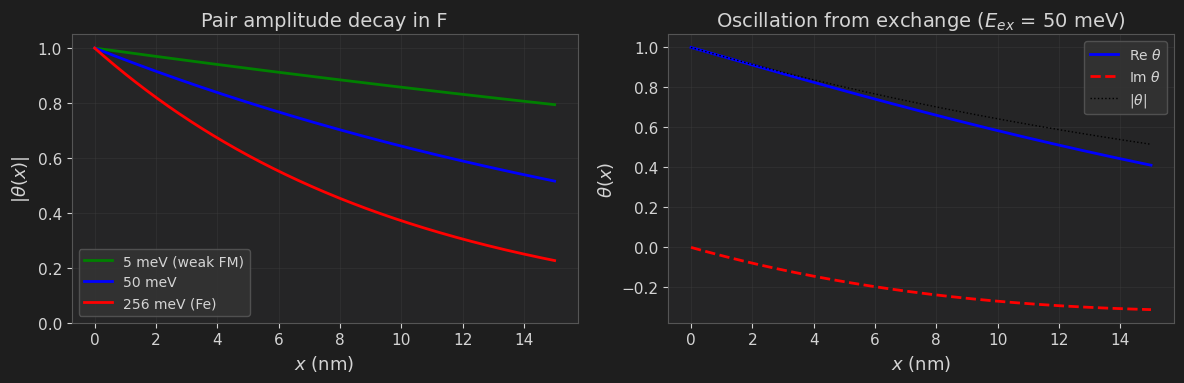

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import supermag
supermag.apply_theme("dark")

# Illustration: linearized Usadel solution in S/F bilayer
# In the F layer, theta is small, so sin(theta) ~ theta
# Solution: theta(x) = A * exp(-kappa * x) with kappa = sqrt(2*(omega + i*E_ex)/D_F)

def usadel_theta_F(x, omega_n, E_ex, D_F):
    """Linearized Usadel solution in the F layer (theta << 1)."""
    kappa = np.sqrt(2 * (omega_n + 1j * E_ex) / D_F)
    return np.exp(-kappa * x)

x = np.linspace(0, 15, 500)  # nm
T = 4.0  # K
omega_1 = np.pi * T  # first Matsubara frequency (K)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: different exchange fields
D_F = 4e-4  # m^2/s (typical)
# Convert to consistent units: E_ex in K, omega in K, D in nm^2/K
# hbar*D/k_B ~ 3.04e5 nm^2*K for D = 4e-4 m^2/s
hbar_D_kB = 3.04e5  # nm^2 * K

for E_ex_meV, color, label in [(5, 'green', '5 meV (weak FM)'),
                                 (50, 'blue', '50 meV'),
                                 (256, 'red', '256 meV (Fe)')]:
    E_ex_K = E_ex_meV * 11.6  # meV to K
    kappa = np.sqrt(2 * (omega_1 + 1j * E_ex_K) / hbar_D_kB)
    theta = np.exp(-kappa * x)
    axes[0].plot(x, np.abs(theta), color=color, linewidth=2, label=label)

axes[0].set_xlabel('$x$ (nm)', fontsize=13)
axes[0].set_ylabel(r'$|\theta(x)|$', fontsize=13)
axes[0].set_title('Pair amplitude decay in F', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.05)

# Right: real and imaginary parts for E_ex = 50 meV
E_ex_K = 50 * 11.6
kappa = np.sqrt(2 * (omega_1 + 1j * E_ex_K) / hbar_D_kB)
theta = np.exp(-kappa * x)
axes[1].plot(x, theta.real, 'b-', linewidth=2, label=r'Re $\theta$')
axes[1].plot(x, theta.imag, 'r--', linewidth=2, label=r'Im $\theta$')
axes[1].plot(x, np.abs(theta), 'k:', linewidth=1, label=r'$|\theta|$')
axes[1].set_xlabel('$x$ (nm)', fontsize=13)
axes[1].set_ylabel(r'$\theta(x)$', fontsize=13)
axes[1].set_title(r'Oscillation from exchange ($E_{ex}$ = 50 meV)', fontsize=14)
axes[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

### Finite-difference discretization

Discretize $\theta(x)$ on a uniform grid $x_j = j\,h$ with $N$ interior points.  The second derivative becomes

$$
\frac{\partial^2\theta}{\partial x^2}\bigg|_{x_j}
\approx \frac{\theta_{j-1} - 2\theta_j + \theta_{j+1}}{h^2}.
$$

Substituting into the linearized Usadel equation (F layer, $\theta\ll 1$):

$$
\frac{D}{h^2}\bigl(\theta_{j-1} - 2\theta_j + \theta_{j+1}\bigr)
+ 2i\bigl(\omega_n + i E_{ex}\bigr)\theta_j = 0.
$$

This is a **tridiagonal system** $\mathbf{A}\boldsymbol\theta = \mathbf{b}$ which can be solved in $\mathcal{O}(N)$ by the Thomas algorithm — exactly the approach implemented in `linalg/tridiag.cpp` with AVX2 vectorisation.

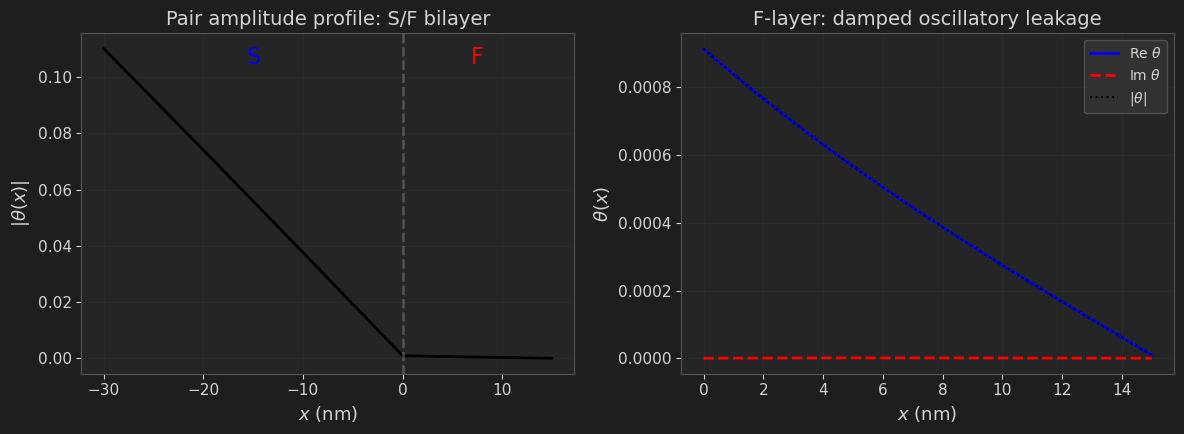

In [3]:
# Finite-difference solution of linearized Usadel in an S/F bilayer
import numpy as np
import matplotlib.pyplot as plt

# --- physical parameters ---
T = 4.0                     # K
omega_1 = np.pi * T         # first Matsubara frequency
E_ex_meV = 50.0
E_ex_K = E_ex_meV * 11.6    # convert to K
hbar_D_kB = 3.04e5          # nm^2·K  (D_F ~ 4e-4 m^2/s)
hbar_DS_kB = 1.2e6          # nm^2·K  (D_S for Nb)
Delta_0 = 1.4               # K (proxy gap)

# --- grid ---
d_S, d_F = 30.0, 15.0       # nm
N_S, N_F = 120, 80
x_S = np.linspace(-d_S, 0, N_S)
x_F = np.linspace(0, d_F, N_F)
h_S, h_F = x_S[1] - x_S[0], x_F[1] - x_F[0]

# --- linearised Usadel on each layer ---
def tridiag_solve(a, b, c, d):
    """Thomas algorithm for tridiagonal Ax = d."""
    n = len(d)
    c_ = np.zeros(n, dtype=complex); d_ = np.zeros(n, dtype=complex)
    c_[0] = c[0] / b[0]; d_[0] = d[0] / b[0]
    for i in range(1, n):
        m = b[i] - a[i] * c_[i - 1]
        c_[i] = c[i] / m
        d_[i] = (d[i] - a[i] * d_[i - 1]) / m
    x = np.zeros(n, dtype=complex)
    x[-1] = d_[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_[i] - c_[i] * x[i + 1]
    return x

# S layer: D_S θ'' + 2ω_n θ + 2Δ = 0  (linearised: sin θ ~ θ, cos θ ~ 1)
diag_S = -2 * hbar_DS_kB / h_S**2 + 2 * omega_1
a_S = np.full(N_S, hbar_DS_kB / h_S**2, dtype=complex)
b_S = np.full(N_S, diag_S, dtype=complex)
c_S = np.full(N_S, hbar_DS_kB / h_S**2, dtype=complex)
rhs_S = np.full(N_S, -2 * Delta_0, dtype=complex)
# BC: θ(-d_S) = arctan(Δ/ω) (bulk BCS)
theta_bulk = np.arctan(Delta_0 / omega_1)
rhs_S[0] -= a_S[0] * theta_bulk
a_S[0] = 0  # boundary row

# F layer: D_F θ'' + 2i(ω + iE_ex) θ = 0
kappa_sq = 2 * (omega_1 + 1j * E_ex_K) / hbar_D_kB
diag_F = -2 * hbar_D_kB / h_F**2 + 2 * 1j * (omega_1 + 1j * E_ex_K)
a_F = np.full(N_F, hbar_D_kB / h_F**2, dtype=complex)
b_F = np.full(N_F, diag_F, dtype=complex)
c_F = np.full(N_F, hbar_D_kB / h_F**2, dtype=complex)
rhs_F = np.zeros(N_F, dtype=complex)
# BC: θ(d_F) = 0
c_F[-1] = 0; rhs_F[-1] = 0

# Simple continuity at x=0: θ_S(0) = θ_F(0), current continuity ignored for illustration
# Solve separately then match amplitude at interface
theta_S = tridiag_solve(a_S, b_S, c_S, rhs_S)
# Fix F boundary: θ_F(0) = θ_S(-1) (last S point)
rhs_F[0] -= a_F[0] * theta_S[-1]
a_F[0] = 0
theta_F = tridiag_solve(a_F, b_F, c_F, rhs_F)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x_all = np.concatenate([x_S, x_F])
theta_all = np.concatenate([theta_S, theta_F])

axes[0].plot(x_all, np.abs(theta_all), 'k-', lw=2)
axes[0].axvline(0, ls='--', color='grey', alpha=0.5)
axes[0].text(-d_S / 2, 0.95 * np.max(np.abs(theta_all)), 'S', fontsize=16, ha='center', color='blue')
axes[0].text(d_F / 2, 0.95 * np.max(np.abs(theta_all)), 'F', fontsize=16, ha='center', color='red')
axes[0].set_xlabel('$x$ (nm)', fontsize=13)
axes[0].set_ylabel(r'$|\theta(x)|$', fontsize=13)
axes[0].set_title(r'Pair amplitude profile: S/F bilayer', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_F, theta_F.real, 'b-', lw=2, label=r'Re $\theta$')
axes[1].plot(x_F, theta_F.imag, 'r--', lw=2, label=r'Im $\theta$')
axes[1].plot(x_F, np.abs(theta_F), 'k:', lw=1.5, label=r'$|\theta|$')
axes[1].set_xlabel('$x$ (nm)', fontsize=13)
axes[1].set_ylabel(r'$\theta(x)$', fontsize=13)
axes[1].set_title('F-layer: damped oscillatory leakage', fontsize=14)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

### SUPERMag Usadel Solver

The `supermag.usadel.solve()` function implements the full finite-difference
scheme (Thomas algorithm + Matsubara summation) via the C++ composable path.
Below we reproduce the S/F bilayer profile from above and sweep the exchange
energy to see how $\xi_F$ controls the oscillation wavelength.

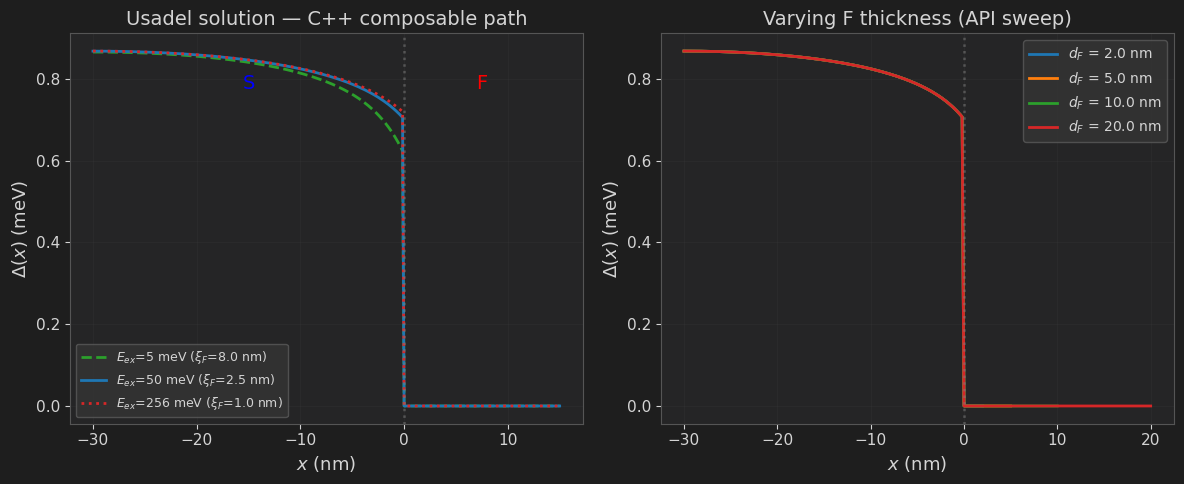

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import supermag

Tc0  = 9.2    # K
d_S  = 30.0   # nm
d_F  = 15.0   # nm
xi_S = 38.0   # nm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: order parameter profile via the composable C++ path
for E_ex, xi_F, col, ls in [(5, 8.0, '#2ca02c', '--'),
                              (50, 2.5, '#1f77b4', '-'),
                              (256, 1.0, '#d62728', ':')]:
    x, Delta = supermag.usadel.solve(Tc0, d_S, d_F, xi_S, xi_F, E_ex, n_grid=400)
    axes[0].plot(x, Delta, color=col, ls=ls, lw=2,
                 label=rf'$E_{{ex}}$={E_ex} meV ($\xi_F$={xi_F} nm)')

axes[0].axvline(0, ls=':', color='grey', alpha=0.5)
axes[0].text(-d_S/2, axes[0].get_ylim()[1]*0.85, 'S', fontsize=14, ha='center', color='blue')
axes[0].text(d_F/2, axes[0].get_ylim()[1]*0.85, 'F', fontsize=14, ha='center', color='red')
axes[0].set_xlabel('$x$ (nm)', fontsize=13)
axes[0].set_ylabel(r'$\Delta(x)$ (meV)', fontsize=13)
axes[0].set_title('Usadel solution — C++ composable path', fontsize=14)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Right: influence of d_F on the S-layer order parameter
d_F_arr = [2.0, 5.0, 10.0, 20.0]
for dF, col in zip(d_F_arr, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    x, Delta = supermag.usadel.solve(Tc0, d_S, dF, xi_S, 2.5, 50.0, n_grid=300)
    axes[1].plot(x, Delta, color=col, lw=2, label=rf'$d_F$ = {dF} nm')

axes[1].axvline(0, ls=':', color='grey', alpha=0.5)
axes[1].set_xlabel('$x$ (nm)', fontsize=13)
axes[1].set_ylabel(r'$\Delta(x)$ (meV)', fontsize=13)
axes[1].set_title('Varying F thickness (API sweep)', fontsize=14)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

### Matsubara convergence

The self-consistency sum
$$\Delta(x) = \lambda\,\pi T \sum_{n=0}^{N_{\max}} \sin\theta(\omega_n, x)$$
converges slowly because $\sin\theta \sim \Delta/\omega_n$ for large $\omega_n$.
In practice one must keep $N_{\max}$ large enough that the truncation error is
below $\sim 1\%$ — typically $N_{\max} \gtrsim \omega_D / (2\pi T)$.

The plot below shows how the partial sum of $\sin\theta$ converges as more
Matsubara frequencies are included.

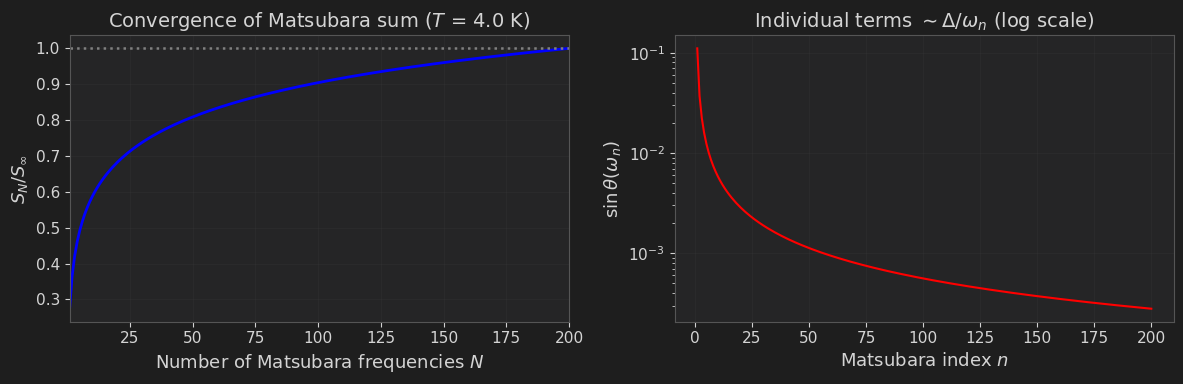

In [7]:
# Matsubara convergence demo
import numpy as np
import matplotlib.pyplot as plt

T = 4.0       # K
Delta = 1.4   # K (BCS gap)
N_max = 200

omega = np.pi * T * (2 * np.arange(N_max) + 1)
sin_theta = Delta / np.sqrt(omega**2 + Delta**2)    # bulk BCS

partial_sum = np.cumsum(sin_theta) * np.pi * T
exact = Delta * np.pi * T * np.sum(sin_theta[:N_max])  # "converged" value

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: partial sum convergence
axes[0].plot(range(1, N_max + 1), partial_sum / partial_sum[-1], 'b-', lw=2)
axes[0].axhline(1.0, ls=':', color='grey')
axes[0].set_xlabel('Number of Matsubara frequencies $N$', fontsize=13)
axes[0].set_ylabel(r'$S_N / S_\infty$', fontsize=13)
axes[0].set_title(f'Convergence of Matsubara sum ($T$ = {T} K)', fontsize=14)
axes[0].set_xlim(1, N_max)
axes[0].grid(True, alpha=0.3)

# Right: individual contributions
axes[1].semilogy(range(1, N_max + 1), sin_theta, 'r-', lw=1.5)
axes[1].set_xlabel('Matsubara index $n$', fontsize=13)
axes[1].set_ylabel(r'$\sin\theta(\omega_n)$', fontsize=13)
axes[1].set_title(r'Individual terms $\sim \Delta/\omega_n$ (log scale)', fontsize=14)
axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

## Numerical Solution Strategy

The Usadel equation is a nonlinear boundary-value problem that is solved
iteratively:

1. **Discretize** $\theta(\omega_n, x)$ on a spatial grid
2. For each Matsubara frequency $\omega_n$, solve the 1D BVP using
   Newton's method (the equation is tridiagonal after discretization)
3. Compute $\Delta(x)$ from the self-consistency sum
4. Repeat until $\Delta$ converges

The Matsubara sum converges slowly; typically $\sim 100$ frequencies are
needed at low temperatures. The nonlinear solve at each $\omega_n$ is
fast (tridiagonal Newton) but must be done carefully near singularities
($\theta \to \pi/2$).

## References

1. Usadel, K.D., "Generalized diffusion equation for superconducting alloys," Phys. Rev. Lett. **25**, 507 (1970).
2. Kupriyanov, M.Yu. & Lukichev, V.F., "Influence of boundary transparency on the critical current of dirty SS'S structures," Sov. Phys. JETP **67**, 1163 (1988).
3. Belzig, W. et al., "Quasiclassical Green's function approach to mesoscopic superconductivity," Superlattices Microstruct. **25**, 1251 (1999).
4. Golubov, A.A., Kupriyanov, M.Yu. & Il'ichev, E., Rev. Mod. Phys. **76**, 411 (2004).